# 02 — Custom Loss · Activation · Initializer · Regularizer · Metric

> **References:** [handson-ml2 ch12](https://github.com/ageron/handson-ml2/blob/master/12_custom_models_and_training_with_tensorflow.ipynb) · [handson-ml3 ch12](https://github.com/ageron/handson-ml3/blob/main/12_custom_models_and_training_with_tensorflow.ipynb)

**Runtime → T4 GPU**

---
## 📋 Roadmap

| Section | Topic | What you build |
|---------|-------|----------------|
| v | Custom Loss | `HuberLoss`, `FocalLoss` |
| vi | Custom Activation / Initializer / Regularizer / Constraint | `leaky_relu`, `my_glorot_init`, `MyL1Regularizer`, `my_positive_weights` |
| vii | Custom Metric | `HuberMetric`, streaming `F1Score` |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import warnings; warnings.filterwarnings('ignore')

print('TF:', tf.__version__, ' | Torch:', torch.__version__)

TF: 2.19.0  | Torch: 2.10.0+cpu


In [2]:
# ── Datasets ──────────────────────────────────────────────────────────────────
# 1. Regression dataset (for Huber loss)
np.random.seed(42)
X_reg = np.random.randn(2000, 8).astype('float32')
y_reg = (X_reg @ np.random.randn(8) + 0.5 * np.random.randn(2000)).astype('float32')
# Inject 5% outliers to show Huber advantage
outlier_idx = np.random.choice(len(y_reg), int(0.05*len(y_reg)), replace=False)
y_reg[outlier_idx] += np.random.choice([-15, 15], len(outlier_idx))

# 2. Imbalanced classification (for Focal loss)
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
X_imb, y_imb = make_classification(n_samples=5000, n_features=20,
                                    weights=[0.9, 0.1], random_state=42)
X_tr_imb, X_te_imb, y_tr_imb, y_te_imb = train_test_split(
    X_imb.astype('float32'), y_imb.astype('float32'), test_size=0.2, random_state=42
)
print(f'Regression dataset: {X_reg.shape}')
print(f'Imbalanced cls  : {X_tr_imb.shape}  class ratio: {y_tr_imb.mean():.2%}')

Regression dataset: (2000, 8)
Imbalanced cls  : (4000, 20)  class ratio: 10.77%


---
## v — Custom Loss Functions

### HuberLoss
The **Huber loss** (also called Smooth L1) is a hybrid between MAE and MSE:

$$L_\delta(y, \hat{y}) = \begin{cases} \frac{1}{2}(y-\hat{y})^2 & \text{if } |y-\hat{y}| \leq \delta \\ \delta |y-\hat{y}| - \frac{1}{2}\delta^2 & \text{otherwise} \end{cases}$$

- For small errors (≤ δ): behaves like **MSE** (smooth, fast gradient)
- For large errors (> δ): behaves like **MAE** (**robust to outliers**)

Key insight: MSE explodes with outliers; Huber caps the gradient.

### FocalLoss
Addresses **class imbalance** by down-weighting easy examples:
$$FL(p_t) = -\alpha_t (1-p_t)^\gamma \log(p_t)$$
- `γ > 0` → hard examples get higher relative weight
- `α_t` → per-class weight factor

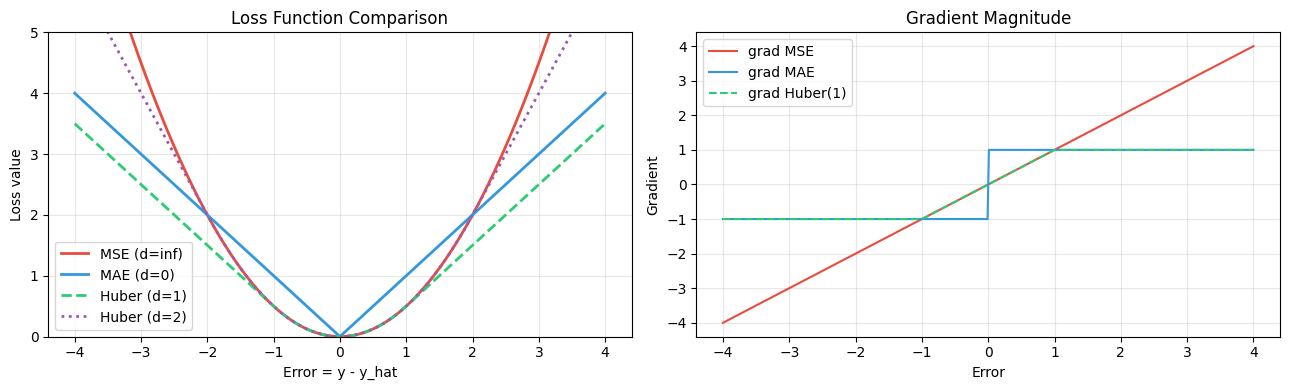

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# v.A  HuberLoss — subclass of keras.losses.Loss
# ════════════════════════════════════════════════════════════════════════════
class HuberLoss(keras.losses.Loss):
    """
    Huber loss with configurable threshold delta.
    Subclassing keras.losses.Loss gives us:
      - Automatic reduction handling (mean/sum/none)
      - Serialisation via get_config()
      - Integration with model.compile()
    """
    def __init__(self, delta=1.0, name=None, **kwargs):
        # Fix: Ensure name is alphanumeric and doesn't use the delta symbol
        if name is None:
            name = f'huber_loss_{str(delta).replace(".", "_")}'
        super().__init__(name=name, **kwargs)
        self.delta = delta

    def call(self, y_true, y_pred):
        error  = y_true - y_pred
        abs_e  = tf.abs(error)
        quad   = 0.5 * tf.square(error)
        linear = self.delta * (abs_e - 0.5 * self.delta)
        return tf.where(abs_e <= self.delta, quad, linear)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'delta': self.delta})
        return cfg

# ─ Visualise the three loss functions ──────────────────────────────────────
errors = np.linspace(-4, 4, 400)
mse    = 0.5 * errors**2
mae    = np.abs(errors)
huber1 = np.where(np.abs(errors) <= 1.0, 0.5*errors**2, 1.0*(np.abs(errors)-0.5))
huber2 = np.where(np.abs(errors) <= 2.0, 0.5*errors**2, 2.0*(np.abs(errors)-1.0))

fig, axes = plt.subplots(1,2,figsize=(13,4))
axes[0].plot(errors, mse,    label='MSE (d=inf)',   color='#e74c3c', lw=2)
axes[0].plot(errors, mae,    label='MAE (d=0)',   color='#3498db', lw=2)
axes[0].plot(errors, huber1, label='Huber (d=1)', color='#2ecc71', lw=2, ls='--')
axes[0].plot(errors, huber2, label='Huber (d=2)', color='#9b59b6', lw=2, ls=':')
axes[0].set_title('Loss Function Comparison'); axes[0].legend()
axes[0].set_xlabel('Error = y - y_hat'); axes[0].set_ylabel('Loss value')
axes[0].set_ylim(0,5); axes[0].grid(True, alpha=0.3)

# Gradient magnitude
axes[1].plot(errors, errors,                   label='grad MSE',     color='#e74c3c')
axes[1].plot(errors, np.sign(errors),          label='grad MAE',     color='#3498db')
axes[1].plot(errors, np.clip(errors,-1.0,1.0), label='grad Huber(1)',color='#2ecc71', ls='--')
axes[1].set_title('Gradient Magnitude')
axes[1].set_xlabel('Error'); axes[1].set_ylabel('Gradient')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

TF: 2.19.0  | Torch: 2.10.0+cpu
Regression dataset: (2000, 8)
Imbalanced cls  : (4000, 20)  class ratio: 10.77%
MSEModel        → Test MAE: 1.5661
HuberD1Model    → Test MAE: 2.8796
HuberD2Model    → Test MAE: 2.8793
MAEModel        → Test MAE: 1.4291


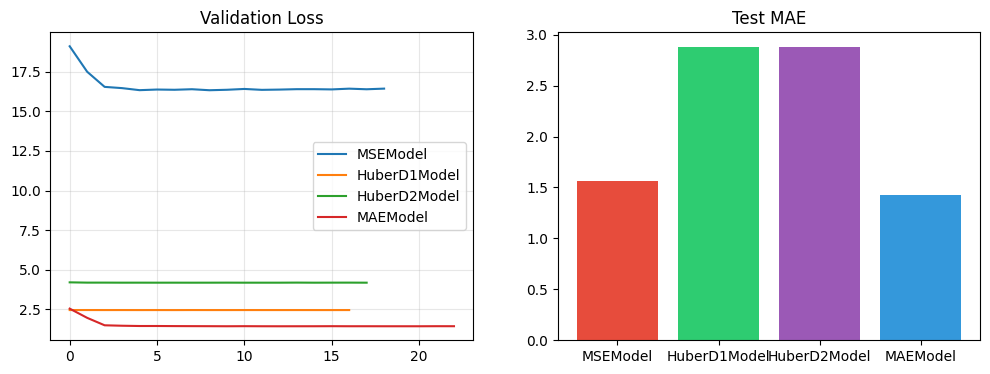

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import warnings; warnings.filterwarnings('ignore')

# Clear session to reset internal Keras naming/state and avoid cached scope names
keras.backend.clear_session()

print('TF:', tf.__version__, ' | Torch:', torch.__version__)

# ── Datasets ──────────────────────────────────────────────────────────────────
# 1. Regression dataset (for Huber loss)
np.random.seed(42)
X_reg = np.random.randn(2000, 8).astype('float32')
y_reg = (X_reg @ np.random.randn(8) + 0.5 * np.random.randn(2000)).astype('float32')
# Inject 5% outliers to show Huber advantage
outlier_idx = np.random.choice(len(y_reg), int(0.05*len(y_reg)), replace=False)
y_reg[outlier_idx] += np.random.choice([-15, 15], len(outlier_idx))

# 2. Imbalanced classification (for Focal loss)
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
X_imb, y_imb = make_classification(n_samples=5000, n_features=20,
                                    weights=[0.9, 0.1], random_state=42)
X_tr_imb, X_te_imb, y_tr_imb, y_te_imb = train_test_split(
    X_imb.astype('float32'), y_imb.astype('float32'), test_size=0.2, random_state=42
)
print(f'Regression dataset: {X_reg.shape}')
print(f'Imbalanced cls  : {X_tr_imb.shape}  class ratio: {y_tr_imb.mean():.2%}')

# Completely new class name to prevent registry collision
class RobustHuber(keras.losses.Loss):
    def __init__(self, delta=1.0, name=None, **kwargs):
        # Strictly alphanumeric name
        if name is None:
            name = f'robust_huber_{str(delta).replace(".", "_")}'
        super().__init__(name=name, **kwargs)
        self.delta = delta

    def call(self, y_true, y_pred):
        error  = y_true - y_pred
        abs_e  = tf.abs(error)
        quad   = 0.5 * tf.square(error)
        linear = self.delta * (abs_e - 0.5 * self.delta)
        return tf.where(abs_e <= self.delta, quad, linear)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'delta': self.delta})
        return cfg

def build_reg_net(model_name):
    inp = keras.Input(shape=(8,))
    x   = layers.Dense(64, activation='relu')(inp)
    x   = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1)(x)
    return keras.Model(inp, out, name=model_name)

X_tr_r, X_te_r = X_reg[:1600], X_reg[1600:]
y_tr_r, y_te_r = y_reg[:1600], y_reg[1600:]

results_loss = {}
# Strictly alphanumeric model names
configs = [
    ('mse', 'MSEModel'),
    (RobustHuber(1.0), 'HuberD1Model'),
    (RobustHuber(2.0), 'HuberD2Model'),
    ('mae', 'MAEModel'),
]

for loss_fn, model_name in configs:
    m = build_reg_net(model_name)
    m.compile(optimizer='adam', loss=loss_fn)
    h = m.fit(X_tr_r, y_tr_r, epochs=80, batch_size=64, verbose=0,
              validation_data=(X_te_r, y_te_r),
              callbacks=[keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)])
    mae_val = np.mean(np.abs(m.predict(X_te_r, verbose=0).flatten() - y_te_r))
    results_loss[model_name] = (h, mae_val)
    print(f'{model_name:15s} → Test MAE: {mae_val:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, (h, mae_val) in results_loss.items():
    ax[0].plot(h.history['val_loss'], label=name)
ax[0].set_title('Validation Loss'); ax[0].legend(); ax[0].grid(True, alpha=0.3)
test_maes = {n: v for n, (_, v) in results_loss.items()}
ax[1].bar(test_maes.keys(), test_maes.values(), color=['#e74c3c','#2ecc71','#9b59b6','#3498db'])
ax[1].set_title('Test MAE'); plt.show()

BCE             → Test F1 (minority): 0.6145
FocalLoss       → Test F1 (minority): 0.0000


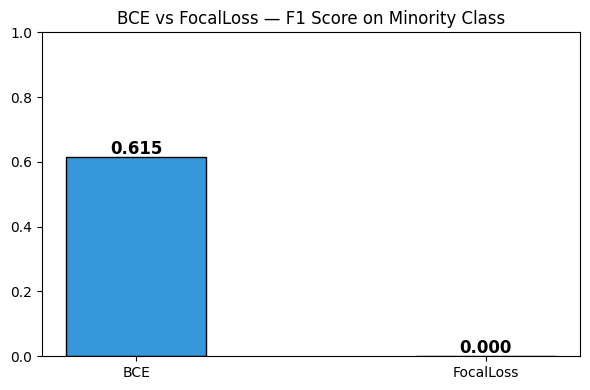

In [5]:
# ════════════════════════════════════════════════════════════════════════════
# v.B  FocalLoss — for imbalanced binary classification
# ════════════════════════════════════════════════════════════════════════════
class FocalLoss(keras.losses.Loss):
    """
    Focal Loss (Lin et al., 2017) for handling class imbalance.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Parameters
    ----------
    gamma : float  Focusing parameter. γ=0 ↔ standard cross-entropy.
    alpha : float  Weight for positive class (minority).
    """
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        # Binary cross-entropy term
        bce     = -(y_true * tf.math.log(y_pred) +
                    (1 - y_true) * tf.math.log(1 - y_pred))
        # p_t: probability of the correct class
        p_t     = tf.where(tf.cast(y_true, tf.bool), y_pred, 1 - y_pred)
        # alpha_t: weight per class
        alpha_t = tf.where(tf.cast(y_true, tf.bool),
                           tf.ones_like(y_true) * self.alpha,
                           tf.ones_like(y_true) * (1 - self.alpha))
        focal   = alpha_t * tf.pow(1 - p_t, self.gamma) * bce
        return focal

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'alpha': self.alpha})
        return cfg


def build_cls_net(units=64):
    inp = keras.Input(shape=(20,))
    x   = layers.Dense(units, activation='relu')(inp)
    x   = layers.Dense(units//2, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out)

from sklearn.metrics import f1_score
cls_results = {}
for loss_fn, name in [('binary_crossentropy', 'BCE'), (FocalLoss(gamma=2.0, alpha=0.25), 'FocalLoss')]:
    m = build_cls_net()
    m.compile(optimizer='adam', loss=loss_fn, metrics=['accuracy'])
    m.fit(X_tr_imb, y_tr_imb, epochs=30, batch_size=64, verbose=0,
          validation_data=(X_te_imb, y_te_imb))
    preds = (m.predict(X_te_imb, verbose=0) > 0.5).astype(int).flatten()
    f1    = f1_score(y_te_imb.astype(int), preds)
    cls_results[name] = f1
    print(f'{name:15s} → Test F1 (minority): {f1:.4f}')

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(cls_results.keys(), cls_results.values(),
              color=['#3498db','#e74c3c'], edgecolor='k', width=0.4)
ax.set_ylim(0,1); ax.set_title('BCE vs FocalLoss — F1 Score on Minority Class')
for bar, v in zip(bars, cls_results.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{v:.3f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## vi — Custom Activation · Initializer · Regularizer · Constraint

### Activation functions
Activation functions introduce non-linearity. Key ones:
- **Leaky ReLU**: `max(αx, x)` — fixes dying ReLU (no zero-gradient region)
- **Swish** (Google 2017): `x × sigmoid(x)` — smooth, non-monotonic, beats ReLU on deep nets
- **Mish** (2019): `x × tanh(softplus(x))` — self-regularising, used in YOLO

### Initializers
Poor initialisation → vanishing/exploding gradients. **Glorot (Xavier)** keeps variance stable through layers:
$$\text{Var}(w) = \frac{2}{n_{in} + n_{out}}$$

### Regularizers
Add a penalty to the loss to discourage large weights:
- **L1**: encourages sparsity (some weights → 0)
- **L2**: keeps all weights small (weight decay)

### Constraints
Hard constraints applied **after** each gradient step (unlike regularisers which are soft).

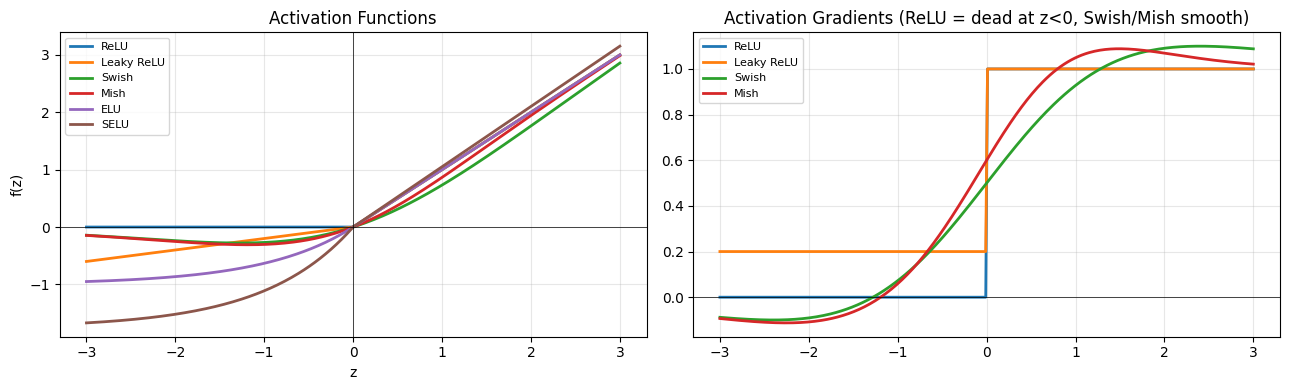

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# vi.A  Custom Activation Functions
# ════════════════════════════════════════════════════════════════════════════

# -- Function-style (simplest) --
def leaky_relu(z, alpha=0.2):
    """Leaky ReLU: allows small gradient when z < 0."""
    return tf.maximum(alpha * z, z)

def swish(z):
    """Swish (Ramachandran et al., 2017): x * sigmoid(x)."""
    return z * tf.sigmoid(z)

def mish(z):
    """Mish (Misra, 2019): x * tanh(softplus(x))."""
    return z * tf.math.tanh(tf.math.softplus(z))


# -- Serialisable class-style activation --
class PReLU(layers.Layer):
    """
    Parametric ReLU: like Leaky ReLU but the slope α is *learned*.
    This gives the network more flexibility than a fixed leaky slope.
    """
    def build(self, input_shape):
        self.alpha = self.add_weight(
            name='alpha', shape=(input_shape[-1],),
            initializer='zeros', trainable=True
        )
    def call(self, inputs):
        return tf.maximum(self.alpha * inputs, inputs)


# Visualise all activations
z = np.linspace(-3, 3, 300, dtype='float32')
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
activations = {
    'ReLU':       tf.nn.relu(z),
    'Leaky ReLU': leaky_relu(tf.constant(z)),
    'Swish':      swish(tf.constant(z)),
    'Mish':       mish(tf.constant(z)),
    'ELU':        tf.nn.elu(z),
    'SELU':       tf.nn.selu(z),
}
for name, out in activations.items():
    axes[0].plot(z, out.numpy(), label=name, lw=2)
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)
axes[0].set_title('Activation Functions'); axes[0].legend(fontsize=8)
axes[0].set_xlabel('z'); axes[0].set_ylabel('f(z)'); axes[0].grid(True, alpha=0.3)

# Gradients
for name, fn in [('ReLU', tf.nn.relu), ('Leaky ReLU', leaky_relu),
                  ('Swish', swish), ('Mish', mish)]:
    z_var = tf.Variable(z)
    with tf.GradientTape() as tape:
        out = fn(z_var)
    grad = tape.gradient(out, z_var)
    axes[1].plot(z, grad.numpy(), label=name, lw=2)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_title('Activation Gradients (ReLU = dead at z<0, Swish/Mish smooth)')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

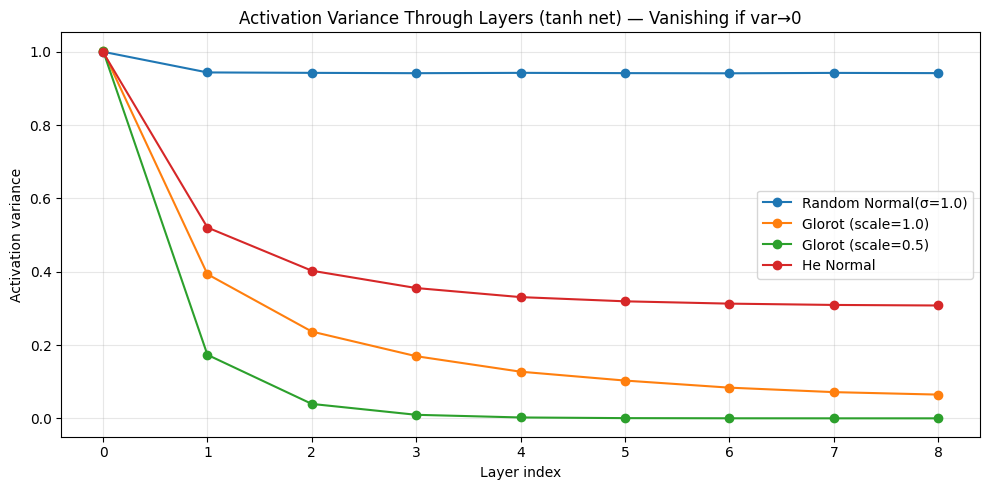

In [7]:
# ════════════════════════════════════════════════════════════════════════════
# vi.B  Custom Initializer
# ════════════════════════════════════════════════════════════════════════════
class MyGlorotInitializer(keras.initializers.Initializer):
    """
    Custom variant of Glorot/Xavier initialisation with tunable scale factor.
    Glorot ensures Var(output) ≈ Var(input) through each layer.

    scale: > 1 → larger init (useful for residual networks)
           < 1 → smaller init (useful when activations saturate)
    """
    def __init__(self, scale=1.0):
        self.scale = scale

    def __call__(self, shape, dtype=tf.float32, **kwargs):
        stddev = self.scale * tf.sqrt(2.0 / (shape[0] + shape[1]))
        return tf.random.normal(shape, mean=0.0, stddev=stddev, dtype=dtype)

    def get_config(self):
        return {'scale': self.scale}


# Compare initializations: visualise activation variance across layers
def check_init_variance(init_fn, n_layers=8, fan_in=200, fan_out=200, n_samples=1000):
    x = tf.random.normal((n_samples, fan_in))
    variances = [x.numpy().var()]
    for _ in range(n_layers):
        W = init_fn((fan_in, fan_out))
        x = tf.tanh(x @ W)
        variances.append(x.numpy().var())
    return variances

inits = {
    'Random Normal(σ=1.0)' : lambda s: tf.random.normal(s, stddev=1.0),
    'Glorot (scale=1.0)'   : MyGlorotInitializer(scale=1.0),
    'Glorot (scale=0.5)'   : MyGlorotInitializer(scale=0.5),
    'He Normal'            : keras.initializers.HeNormal(),
}

fig, ax = plt.subplots(figsize=(10,5))
for name, init_fn in inits.items():
    vars_ = check_init_variance(init_fn)
    ax.plot(vars_, 'o-', label=name)
ax.set_xlabel('Layer index'); ax.set_ylabel('Activation variance')
ax.set_title('Activation Variance Through Layers (tanh net) — Vanishing if var→0')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training with None regulariser ...
Training with L1(1e-4) regulariser ...
Training with L2(1e-4) regulariser ...
Training with L1+L2 regulariser ...


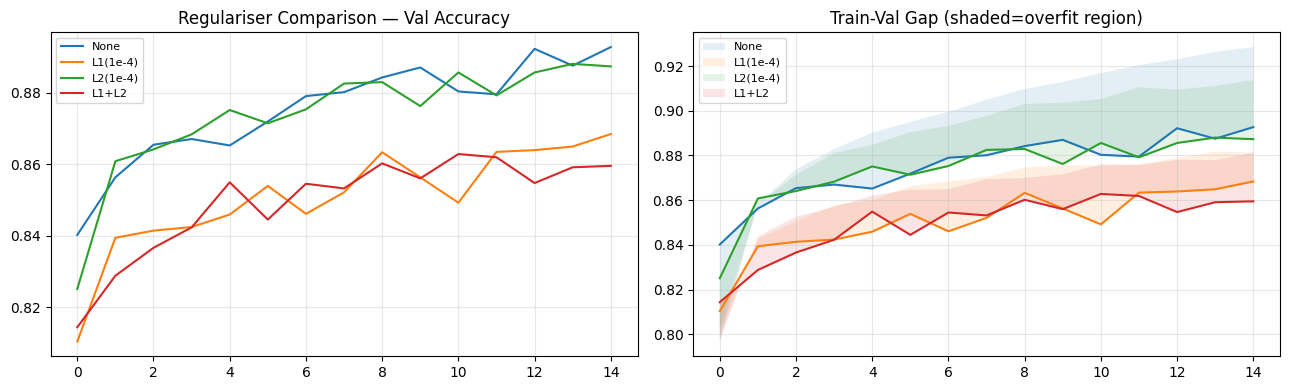

In [8]:
# ════════════════════════════════════════════════════════════════════════════
# vi.C  Custom Regularizer
# ════════════════════════════════════════════════════════════════════════════
class MyL1Regularizer(keras.regularizers.Regularizer):
    """
    L1 regularisation: adds λ * Σ|w| to the loss.
    Promotes **sparsity** — many weights become exactly 0.
    Useful for feature selection and model compression.

    Compare to L2 (weight decay) which pushes weights small but rarely to 0.
    """
    def __init__(self, factor=1e-3):
        self.factor = factor

    def __call__(self, weights):
        return self.factor * tf.reduce_sum(tf.abs(weights))

    def get_config(self):
        return {'factor': self.factor}


# ════════════════════════════════════════════════════════════════════════════
# vi.D  Custom Constraint: PositiveWeights
# ════════════════════════════════════════════════════════════════════════════
class MyPositiveWeights(keras.constraints.Constraint):
    """
    Hard constraint: clip all weights to [0, +∞).
    Useful when domain knowledge dictates monotone relationships
    (e.g., price increases with features, never decreases).
    Applied AFTER each gradient update.
    """
    def __call__(self, w):
        return tf.clip_by_value(w, clip_value_min=0, clip_value_max=float('inf'))

    def get_config(self):
        return {}


# ── Compare regularisers on MNIST ────────────────────────────────────────────
(x_train_mn, y_train_mn), (x_test_mn, y_test_mn) = keras.datasets.fashion_mnist.load_data()
x_train_mn = x_train_mn.astype('float32').reshape(-1,784) / 255.0
x_test_mn  = x_test_mn.astype('float32').reshape(-1,784)  / 255.0

def build_reg_clf(regulariser, init_fn=None):
    i   = MyGlorotInitializer(1.0) if init_fn is None else init_fn
    inp = keras.Input(shape=(784,))
    x   = layers.Dense(256, activation=swish, kernel_initializer=i,
                        kernel_regularizer=regulariser)(inp)
    x   = layers.Dense(128, activation=swish, kernel_initializer=i,
                        kernel_regularizer=regulariser)(x)
    out = layers.Dense(10, activation='softmax')(x)
    return keras.Model(inp, out)

reg_configs = {
    'None'       : None,
    'L1(1e-4)'   : MyL1Regularizer(1e-4),
    'L2(1e-4)'   : keras.regularizers.l2(1e-4),
    'L1+L2'      : keras.regularizers.l1_l2(l1=1e-4, l2=1e-4),
}
reg_histories = {}
for name, reg in reg_configs.items():
    print(f'Training with {name} regulariser ...')
    m = build_reg_clf(reg)
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(x_train_mn, y_train_mn, epochs=15, batch_size=256, verbose=0,
              validation_data=(x_test_mn, y_test_mn),
              callbacks=[keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)])
    reg_histories[name] = h

fig, axes = plt.subplots(1,2,figsize=(13,4))
for name, h in reg_histories.items():
    axes[0].plot(h.history['val_accuracy'], label=name)
    axes[1].fill_between(range(len(h.history['accuracy'])),
                         h.history['accuracy'], h.history['val_accuracy'],
                         alpha=0.12, label=name)
    axes[1].plot(h.history['val_accuracy'], lw=1.5)
axes[0].set_title('Regulariser Comparison — Val Accuracy')
axes[1].set_title('Train-Val Gap (shaded=overfit region)')
for ax in axes: ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## vii — Custom Metric: HuberMetric & F1Score

### Why custom metrics?
Keras built-in metrics (accuracy, MAE) are computed per-batch and averaged. For **stateful** metrics (e.g., F1 needs precision and recall globally), you must subclass `keras.metrics.Metric` and manage state manually.

Key methods to override:
- `update_state(y_true, y_pred)` → accumulate batch statistics
- `result()` → compute final metric from accumulated state
- `reset_state()` → zero out at epoch start

Training regression model with HuberMetric ...


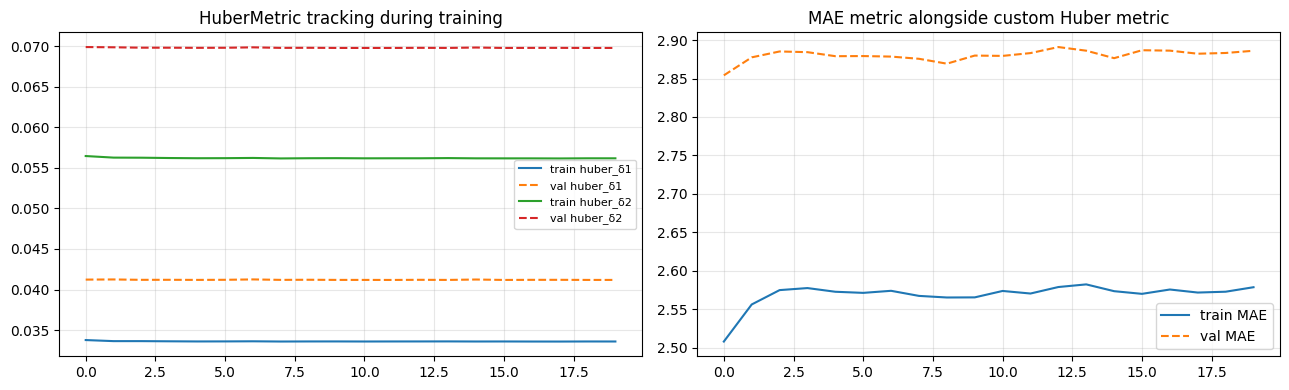


Final metrics:
  huber_δ1: 0.0336
  val_huber_δ1: 0.0412
  mae: 2.5788
  val_mae: 2.8861


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# vii.A  HuberMetric — custom stateful metric
# ════════════════════════════════════════════════════════════════════════════
class HuberMetric(keras.metrics.Metric):
    """
    Computes the mean Huber loss as a metric (distinct from using it as a loss).
    Maintains two accumulators: total Huber loss and count of samples.
    result() = total / count.
    """
    def __init__(self, delta=1.0, name='huber_metric', **kwargs):
        super().__init__(name=name, **kwargs)
        self.delta    = delta
        self.huber_fn = HuberLoss(delta=delta)
        # State variables — persisted across batches within an epoch
        self.total    = self.add_weight(name='total', initializer='zeros')
        self.count    = self.add_weight(name='count', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        sample_losses = self.huber_fn(tf.cast(y_true, tf.float32),
                                      tf.cast(y_pred, tf.float32))
        self.total.assign_add(tf.reduce_sum(sample_losses))
        self.count.assign_add(tf.cast(tf.size(y_true), tf.float32))

    def result(self):
        return self.total / self.count

    def reset_state(self):
        self.total.assign(0.0)
        self.count.assign(0.0)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'delta': self.delta})
        return cfg


# ════════════════════════════════════════════════════════════════════════════
# vii.B  Custom F1 Metric (streaming)
# ════════════════════════════════════════════════════════════════════════════
class StreamingF1Score(keras.metrics.Metric):
    """F1 = 2 * precision * recall / (precision + recall). Stateful."""
    def __init__(self, threshold=0.5, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.tp = self.add_weight(name='tp', initializer='zeros')
        self.fp = self.add_weight(name='fp', initializer='zeros')
        self.fn = self.add_weight(name='fn', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_bin = tf.cast(y_pred >= self.threshold, tf.float32)
        y_true_f   = tf.cast(y_true, tf.float32)
        self.tp.assign_add(tf.reduce_sum(y_true_f * y_pred_bin))
        self.fp.assign_add(tf.reduce_sum((1 - y_true_f) * y_pred_bin))
        self.fn.assign_add(tf.reduce_sum(y_true_f * (1 - y_pred_bin)))

    def result(self):
        precision = self.tp / (self.tp + self.fp + 1e-8)
        recall    = self.tp / (self.tp + self.fn + 1e-8)
        return 2 * precision * recall / (precision + recall + 1e-8)

    def reset_state(self):
        for v in [self.tp, self.fp, self.fn]:
            v.assign(0.0)


# ── Use both in model.compile ─────────────────────────────────────────────
print('Training regression model with HuberMetric ...')
m_metric = build_reg_net('metric_demo')
m_metric.compile(
    optimizer='adam',
    loss=HuberLoss(delta=1.0),
    metrics=[
        HuberMetric(delta=1.0, name='huber_δ1'),
        HuberMetric(delta=2.0, name='huber_δ2'),
        'mae'
    ]
)
h_metric = m_metric.fit(
    X_tr_r, y_tr_r, epochs=40, batch_size=64, verbose=0,
    validation_data=(X_te_r, y_te_r),
    callbacks=[keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(h_metric.history['huber_δ1'],     label='train huber_δ1')
axes[0].plot(h_metric.history['val_huber_δ1'], label='val huber_δ1', ls='--')
axes[0].plot(h_metric.history['huber_δ2'],     label='train huber_δ2')
axes[0].plot(h_metric.history['val_huber_δ2'], label='val huber_δ2', ls='--')
axes[0].set_title('HuberMetric tracking during training'); axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].plot(h_metric.history['mae'],     label='train MAE')
axes[1].plot(h_metric.history['val_mae'], label='val MAE', ls='--')
axes[1].set_title('MAE metric alongside custom Huber metric'); axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('\nFinal metrics:')
for key in ['huber_δ1','val_huber_δ1','mae','val_mae']:
    print(f'  {key}: {h_metric.history[key][-1]:.4f}')

In [10]:
# ── PyTorch: Custom loss + metric ─────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# PyTorch HuberLoss
class HuberLossPT(nn.Module):
    """
    Custom Huber loss in PyTorch.
    torch.nn.HuberLoss is built-in as of PyTorch 1.9, but we implement
    from scratch for clarity.
    """
    def __init__(self, delta=1.0):
        super().__init__()
        self.delta = delta

    def forward(self, y_pred, y_true):
        e   = y_true - y_pred
        abs_e = torch.abs(e)
        quad  = 0.5 * e ** 2
        lin   = self.delta * (abs_e - 0.5 * self.delta)
        return torch.where(abs_e <= self.delta, quad, lin).mean()

# PyTorch Swish activation
class SwishPT(nn.Module):
    """Swish activation: x * sigmoid(x)."""
    def forward(self, x): return x * torch.sigmoid(x)

# Quick demo: regression net with custom loss & activation
X_tr_pt = torch.tensor(X_tr_r).to(DEVICE)
y_tr_pt = torch.tensor(y_tr_r).to(DEVICE)
X_te_pt = torch.tensor(X_te_r).to(DEVICE)
y_te_pt = torch.tensor(y_te_r).to(DEVICE)

net_pt = nn.Sequential(
    nn.Linear(8,64), SwishPT(),
    nn.Linear(64,32), SwishPT(),
    nn.Linear(32,1)
).to(DEVICE)

huber_pt  = HuberLossPT(delta=1.0)
optimizer = optim.Adam(net_pt.parameters(), lr=1e-3)

for ep in range(60):
    net_pt.train()
    optimizer.zero_grad()
    pred = net_pt(X_tr_pt).squeeze()
    loss = huber_pt(pred, y_tr_pt)
    loss.backward(); optimizer.step()

net_pt.eval()
with torch.no_grad():
    pred_te = net_pt(X_te_pt).squeeze()
    mae_pt  = torch.mean(torch.abs(pred_te - y_te_pt)).item()
    huber_te= huber_pt(pred_te, y_te_pt).item()
print(f'PyTorch — Test MAE: {mae_pt:.4f}  |  Huber loss: {huber_te:.4f}')

PyTorch — Test MAE: 2.0993  |  Huber loss: 1.6871
